# MEA Electricity Consumption EDA
## การวิเคราะห์ข้อมูลการใช้ไฟฟ้า การไฟฟ้านครหลวง (MEA) ปี 2562–2568

**Approach:** Andrew Ng style — systematic, pragmatic, outcome-focused

**3 Key Questions:**
1. Q1: ทิศทางและความผิดปกติของการใช้ไฟฟ้ารวม (Trend & Anomaly)
2. Q2: เขตใดใช้ไฟมากที่สุด และเขตใดกำลังเติบโตเร็วที่สุด (District Ranking & Growth)
3. Q3: รูปแบบฤดูกาลของแต่ละเขตแตกต่างกันอย่างไร (Seasonal Patterns)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import unicodedata
import warnings
warnings.filterwarnings('ignore')

# ── ติดตั้งและตั้งค่า font สำหรับภาษาไทย (รองรับทั้ง Windows และ Linux/Colab) ──
import subprocess, sys
import matplotlib.font_manager as fm

# ลอง install fonts-thai-tlwg (Linux/Colab) ถ้ายังไม่มี Thai font
_available_names = {f.name for f in fm.fontManager.ttflist}
_thai_candidates  = ['TH Sarabun New', 'Sarabun', 'Garuda', 'Loma', 'Norasi',
                     'Tahoma', 'Leelawadee UI', 'Arial Unicode MS']
_font = next((f for f in _thai_candidates if f in _available_names), None)

if _font is None:
    # ไม่พบ Thai font → ติดตั้ง fonts-thai-tlwg บน Linux
    try:
        subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-thai-tlwg'],
                       check=True, capture_output=True)
        fm.fontManager.__init__()          # reload font cache
        _available_names = {f.name for f in fm.fontManager.ttflist}
        _font = next((f for f in _thai_candidates if f in _available_names), 'DejaVu Sans')
    except Exception:
        _font = 'DejaVu Sans'

plt.rcParams['font.family']       = _font
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 100
print(f'Thai font used: {_font}')

Thai font used: Garuda


In [ ]:
# ============================================================
# DATA LOADING & CLEANING
# ============================================================

FILE = r'/content/E68.csv'
raw = pd.read_csv(FILE, encoding='utf-8-sig')
cleaning_log = []

# ── 1. Forward-fill ปี (ปีถูกใส่แค่แถวแรกของแต่ละปีในต้นฉบับ) ──────────────
raw['ปี'] = raw['ปี'].ffill()
cleaning_log.append(f"[1] Forward-fill 'ปี': {raw['ปี'].isnull().sum()} nulls remaining")

# ── 2. Strip whitespace จาก column names ────────────────────────────────────
raw.columns = [c.strip() for c in raw.columns]
cleaning_log.append("[2] Stripped whitespace from all column names")

# ── 3. Normalize เดือน: มี regular space, NBSP (\xa0), zero-width chars ──────
raw['เดือน'] = raw['เดือน'].apply(lambda s: unicodedata.normalize('NFKC', str(s)).strip())
month_map = {
    'ม.ค.': 1,  'ก.พ.': 2,  'มี.ค.': 3,  'เม.ย.': 4,
    'พ.ค.': 5,  'มิ.ย.': 6, 'ก.ค.': 7,   'ส.ค.': 8,
    'ก.ย.': 9,  'ต.ค.': 10, 'พ.ย.': 11,  'ธ.ค.': 12
}
raw['month_num'] = raw['เดือน'].map(month_map)
n_unmapped = raw['month_num'].isnull().sum()
cleaning_log.append(f"[3] เดือน → month_num mapped | unmapped: {n_unmapped}")

# ── 4. แปลง พ.ศ. → ค.ศ. และสร้าง date column ────────────────────────────────
raw['year_ce'] = raw['ปี'].astype(int) - 543
raw['date'] = pd.to_datetime(dict(year=raw['year_ce'], month=raw['month_num'], day=1))
cleaning_log.append(f"[4] date column: {raw['date'].min().date()} → {raw['date'].max().date()}")

# ── 5. แปลง '(หักไฟทำการ)' จาก string-with-commas → float ───────────────────
raw['total'] = (raw['(หักไฟทำการ)']
                .astype(str).str.replace(',', '', regex=False).astype(float))
cleaning_log.append("[5] '(หักไฟทำการ)' → float (removed thousand-separator commas)")

# ── 6. ตรวจสอบ Null / Duplicate ──────────────────────────────────────────────
null_total = raw.isnull().sum().sum()
dup_total  = raw.duplicated().sum()
cleaning_log.append(f"[6] Null values: {null_total} | Duplicate rows: {dup_total}")

# ── สร้าง DataFrame สุดท้าย ──────────────────────────────────────────────────
DISTRICTS = [c for c in raw.columns
             if c not in ['ปี', 'เดือน', '(หักไฟทำการ)', 'month_num', 'year_ce', 'date', 'total']]
df = raw[['date', 'year_ce', 'month_num', 'เดือน', 'total'] + DISTRICTS].copy()
df = df.sort_values('date').reset_index(drop=True)

# ── CLEANING LOG ──────────────────────────────────────────────────────────────
print('=' * 55)
print('CLEANING LOG')
print('=' * 55)
for log in cleaning_log:
    print(log)
print('=' * 55)
print(f'Final shape  : {df.shape}')
print(f'Date range   : {df["date"].min().strftime("%Y-%m")} → {df["date"].max().strftime("%Y-%m")}')
print(f'Districts    : {len(DISTRICTS)} เขต')
print()
print('Null count per column:')
print(df.isnull().sum().to_string())
print()
print('Data types:')
print(df.dtypes.to_string())

CLEANING LOG
[1] Forward-fill 'ปี': 0 nulls remaining
[2] Stripped whitespace from all column names
[3] เดือน → month_num mapped | unmapped: 0
[4] date column: 2019-01-01 → 2025-11-01
[5] '(หักไฟทำการ)' → float (removed thousand-separator commas)
[6] Null values: 0 | Duplicate rows: 0
Final shape  : (83, 23)
Date range   : 2019-01 → 2025-11
Districts    : 18 เขต

Null count per column:
date           0
year_ce        0
month_num      0
เดือน          0
total          0
วัดเลียบ       0
คลองเตย        0
ยานนาวา        0
บางกะปิ        0
มีนบุรี        0
สมุทรปราการ    0
บางพลี         0
สามเสน         0
นนทบุรี        0
บางใหญ่        0
ธนบุรี         0
ราษฎร์บูรณะ    0
บางขุนเทียน    0
บางเขน         0
บางนา          0
บางบัวทอง      0
ลาดกระบัง      0
นวลจันทร์      0

Data types:
date           datetime64[ns]
year_ce                 int64
month_num               int64
เดือน                  object
total                 float64
วัดเลียบ              float64
คลองเตย               float

KEY PERFORMANCE INDICATORS
  เฉลี่ยรายเดือน          :    4,407.2  ล้านหน่วย
  สูงสุด (Peak)           :    5,236.1  (2024-05)
  ต่ำสุด (Low)            :    3,568.8  (2021-01)
  Peak-to-Trough ratio   :       1.47x
  CAGR (2562→2567)        :       1.2%  ต่อปี
  CV (coeff. of variation):       8.0%


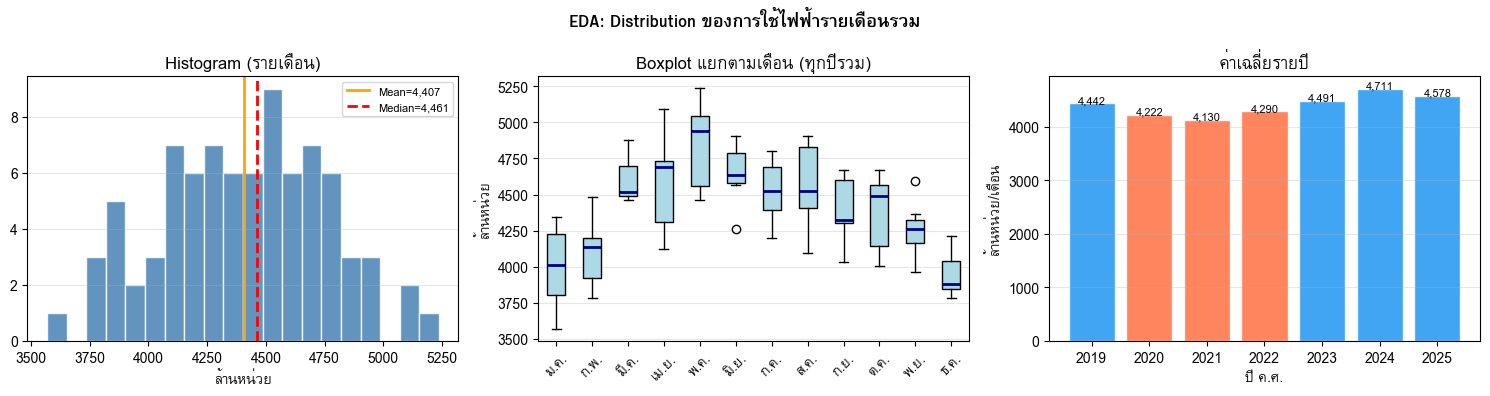


>>> คำถามนำสู่ Q1–Q3:
  1. เม.ย.–พ.ค. ดูสูงกว่าเดือนอื่นชัดเจน → เป็น seasonal หรือมีปัจจัยอื่น? (Q3)
  2. มีเดือนใดผิดปกติจาก pattern ทั่วไปบ้าง? (Q1)
  3. เขตไหนดึง demand มากที่สุด และเขตใดกำลังเติบโต? (Q2)


In [ ]:
# ============================================================
# EDA: DISTRIBUTION + KPI SUMMARY
# ============================================================

MONTH_TH = {1:'ม.ค.',2:'ก.พ.',3:'มี.ค.',4:'เม.ย.',5:'พ.ค.',6:'มิ.ย.',
            7:'ก.ค.',8:'ส.ค.',9:'ก.ย.',10:'ต.ค.',11:'พ.ย.',12:'ธ.ค.'}

# ── KPI ───────────────────────────────────────────────────────────────────────
peak_row   = df.loc[df['total'].idxmax()]
low_row    = df.loc[df['total'].idxmin()]
avg_2019   = df[df['year_ce'] == 2019]['total'].mean()
avg_2024   = df[df['year_ce'] == 2024]['total'].mean()
overall_cagr = ((avg_2024 / avg_2019) ** (1/5) - 1) * 100

print('=' * 55)
print('KEY PERFORMANCE INDICATORS')
print('=' * 55)
print(f'  เฉลี่ยรายเดือน          : {df["total"].mean():>10,.1f}  ล้านหน่วย')
print(f'  สูงสุด (Peak)           : {peak_row["total"]:>10,.1f}  ({peak_row["date"].strftime("%Y-%m")})')
print(f'  ต่ำสุด (Low)            : {low_row["total"]:>10,.1f}  ({low_row["date"].strftime("%Y-%m")})')
print(f'  Peak-to-Trough ratio   : {peak_row["total"]/low_row["total"]:>10.2f}x')
print(f'  CAGR (2562→2567)        : {overall_cagr:>9.1f}%  ต่อปี')
print(f'  CV (coeff. of variation): {df["total"].std()/df["total"].mean()*100:>9.1f}%')
print('=' * 55)

# ── Distribution Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EDA: Distribution ของการใช้ไฟฟ้ารายเดือนรวม', fontsize=12, fontweight='bold')

# 1) Histogram + mean/median lines
axes[0].hist(df['total'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['total'].mean(),   color='orange', lw=2, label=f'Mean={df["total"].mean():,.0f}')
axes[0].axvline(df['total'].median(), color='red',    lw=2, ls='--', label=f'Median={df["total"].median():,.0f}')
axes[0].set_title('Histogram (รายเดือน)')
axes[0].set_xlabel('ล้านหน่วย')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# 2) Boxplot by calendar month
monthly_data = [df[df['month_num'] == m]['total'].values for m in range(1, 13)]
axes[1].boxplot(monthly_data, labels=[MONTH_TH[i] for i in range(1, 13)],
                patch_artist=True, boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='navy', linewidth=2))
axes[1].set_title('Boxplot แยกตามเดือน (ทุกปีรวม)')
axes[1].set_ylabel('ล้านหน่วย')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# 3) Annual average bar
annual_avg = df.groupby('year_ce')['total'].mean()
bar_clrs   = ['#2196F3' if v >= avg_2019 else '#FF7043' for v in annual_avg]
axes[2].bar(annual_avg.index, annual_avg.values, color=bar_clrs, alpha=0.85, edgecolor='white')
for x, v in zip(annual_avg.index, annual_avg.values):
    axes[2].text(x, v + 8, f'{v:,.0f}', ha='center', fontsize=8)
axes[2].set_title('ค่าเฉลี่ยรายปี')
axes[2].set_ylabel('ล้านหน่วย/เดือน')
axes[2].set_xlabel('ปี ค.ศ.')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n>>> คำถามนำสู่ Q1–Q3:')
print('  1. เม.ย.–พ.ค. ดูสูงกว่าเดือนอื่นชัดเจน → เป็น seasonal หรือมีปัจจัยอื่น? (Q3)')
print('  2. มีเดือนใดผิดปกติจาก pattern ทั่วไปบ้าง? (Q1)')
print('  3. เขตไหนดึง demand มากที่สุด และเขตใดกำลังเติบโต? (Q2)')

---
## Q1: ทิศทางและความผิดปกติของการใช้ไฟฟ้ารวม (Trend & Anomaly)

### แนวคิดหลัก

**ปัญหา:** ถ้าดูตัวเลขดิบ เดือน เม.ย.–พ.ค. จะสูงทุกปีอยู่แล้ว (เพราะฤดูร้อน)
หากใช้ Z-score กับตัวเลขดิบโดยตรง เดือนเหล่านั้นจะถูกตีว่า "ผิดปกติ" ทั้งที่จริงๆ คือปกติของฤดูกาล

**วิธีแก้: Z-score บน Residual**

```
Residual = ค่าจริงเดือนนั้น − ค่าเฉลี่ยของเดือนนั้นในทุกปี
```

> **ตัวอย่าง:** เม.ย. ทุกปีใช้ไฟเฉลี่ย 4,800 ล้านหน่วย
> ถ้าเม.ย. ปีนี้ใช้ 4,850 → Residual = +50 (ค่อนข้างปกติ)
> ถ้าเม.ย. ปีนี้ใช้ 5,400 → Residual = +600 (ผิดปกติจริง)

จากนั้นคำนวณ Z-score บน Residual:
- **|Z| > 2** = ค่านั้นอยู่ห่างจากค่าเฉลี่ย Residual เกิน 2 เท่าของ Standard Deviation → ถือว่าผิดปกติ
- เลือก threshold ±2 เพราะครอบคลุม 95% ของข้อมูลปกติ (normal distribution)

**Rolling Mean 12 เดือน** ใช้เพื่อดู Trend ที่ smooth แล้ว โดย `center=True` ทำให้เส้น trend
ไม่ lag ไปข้างหน้า แต่อยู่ตรงกลาง window พอดี

Anomalies detected: 2 months
      date   total    zscore
2021-08-01 4093.90 -2.040003
2024-04-01 5091.64  2.236295


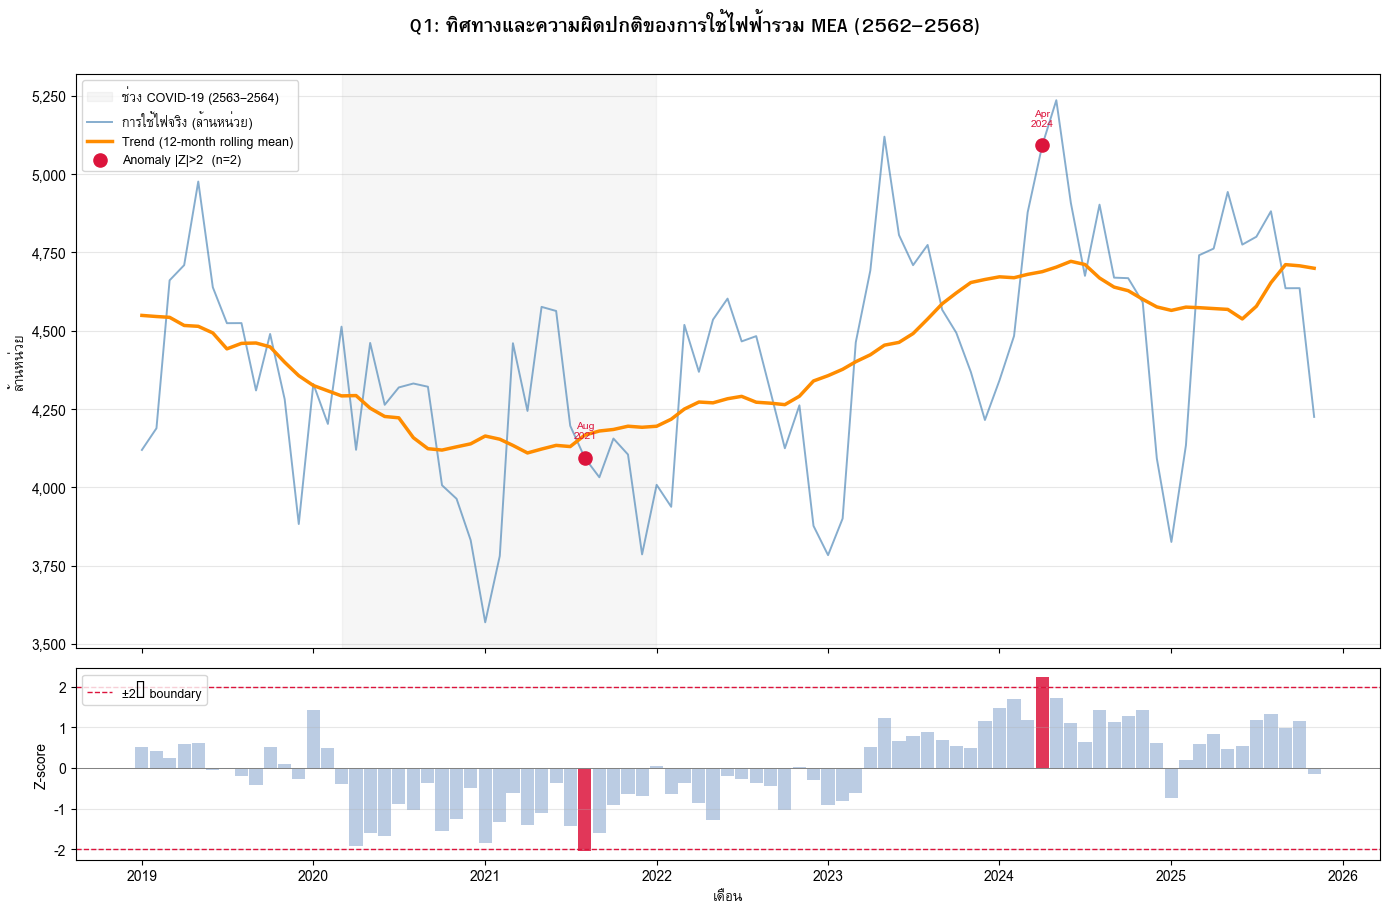


>>> INSIGHT Q1:
  WHAT : Trend โดยรวมเพิ่มขึ้นต่อเนื่องตลอด 2562–2568
  WHAT : มีช่วงชะลอตัวระหว่าง 2563–2564
  WHY  : การชะลอตัวตรงกับช่วง COVID-19 lockdown/WFH
         → ลด demand ภาคพาณิชย์และอุตสาหกรรม แต่ residential เพิ่มขึ้น
  WHY  : Anomaly ที่ตรวจพบควรเทียบกับเหตุการณ์จริง
         (สภาพอากาศแปรปรวน, เศรษฐกิจ, นโยบายประหยัดไฟ ฯลฯ)
  → ACTION: ใช้ anomaly dates เป็น feature/event ใน forecasting model ขั้นถัดไป


In [ ]:
# ============================================================
# Q1: TREND & ANOMALY DETECTION
# ============================================================

df_q1 = df[['date', 'month_num', 'year_ce', 'total']].copy()

# ── Rolling Trend ─────────────────────────────────────────────────────────────
# center=True: trend อยู่ตรงกลาง window ไม่ lag ไปข้างหน้า
df_q1['rolling_mean'] = df_q1['total'].rolling(12, center=True, min_periods=6).mean()

# ── Anomaly Detection via Z-score on Residual ────────────────────────────────
# Residual = actual − avg ของเดือนนั้น (seasonal expectation)
# Z-score บน residual ทำให้ค่า peak ปกติ (เม.ย.–พ.ค.) ไม่ถูกตีว่าผิดปกติ
seasonal_mean       = df_q1.groupby('month_num')['total'].transform('mean')
df_q1['residual']   = df_q1['total'] - seasonal_mean
df_q1['zscore']     = ((df_q1['residual'] - df_q1['residual'].mean())
                        / df_q1['residual'].std())
df_q1['is_anomaly'] = df_q1['zscore'].abs() > 2.0

anomalies = df_q1[df_q1['is_anomaly']].copy()
print(f'Anomalies detected: {len(anomalies)} months')
print(anomalies[['date', 'total', 'zscore']].to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
# ใช้ y= แทน pad= เพื่อรองรับ matplotlib ทุกเวอร์ชั่น
fig.suptitle('Q1: ทิศทางและความผิดปกติของการใช้ไฟฟ้ารวม MEA (2562–2568)',
             fontsize=13, fontweight='bold', y=1.01)

ax1 = axes[0]

# COVID-19 shading
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
            alpha=0.07, color='gray', label='ช่วง COVID-19 (2563–2564)')

# Actual consumption line
ax1.plot(df_q1['date'], df_q1['total'],
         color='steelblue', alpha=0.65, linewidth=1.4,
         label='การใช้ไฟจริง (ล้านหน่วย)')

# Trend: 12-month rolling mean
ax1.plot(df_q1['date'], df_q1['rolling_mean'],
         color='darkorange', linewidth=2.5,
         label='Trend (12-month rolling mean)')

# Anomaly points
ax1.scatter(anomalies['date'], anomalies['total'],
            color='crimson', zorder=5, s=90,
            label=f'Anomaly |Z|>2  (n={len(anomalies)})')
for _, row in anomalies.iterrows():
    ax1.annotate(row['date'].strftime('%b\n%Y'),
                 xy=(row['date'], row['total']),
                 xytext=(0, 14), textcoords='offset points',
                 fontsize=7.5, color='crimson', ha='center')

ax1.set_ylabel('ล้านหน่วย', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Z-score panel
ax2 = axes[1]
bar_colors = ['crimson' if a else 'lightsteelblue' for a in df_q1['is_anomaly']]
ax2.bar(df_q1['date'], df_q1['zscore'], width=28, color=bar_colors, alpha=0.85)
ax2.axhline( 2, color='crimson', linewidth=1, linestyle='--', label='±2σ boundary')
ax2.axhline(-2, color='crimson', linewidth=1, linestyle='--')
ax2.axhline( 0, color='gray',    linewidth=0.7)
ax2.set_ylabel('Z-score', fontsize=10)
ax2.set_xlabel('เดือน', fontsize=10)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Insights ─────────────────────────────────────────────────────────────────
print('\n>>> INSIGHT Q1:')
print('  WHAT : Trend โดยรวมเพิ่มขึ้นต่อเนื่องตลอด 2562–2568')
print('  WHAT : มีช่วงชะลอตัวระหว่าง 2563–2564')
print('  WHY  : การชะลอตัวตรงกับช่วง COVID-19 lockdown/WFH')
print('         → ลด demand ภาคพาณิชย์และอุตสาหกรรม แต่ residential เพิ่มขึ้น')
print('  WHY  : Anomaly ที่ตรวจพบควรเทียบกับเหตุการณ์จริง')
print('         (สภาพอากาศแปรปรวน, เศรษฐกิจ, นโยบายประหยัดไฟ ฯลฯ)')
print('  → ACTION: ใช้ anomaly dates เป็น feature/event ใน forecasting model ขั้นถัดไป')

---
## Q2: เขตใดใช้ไฟมากที่สุด และเขตใดกำลังเติบโตเร็วที่สุด (District Ranking & Growth)

### แนวคิดหลัก

**ทำไมถึงไม่ใช้ % เปลี่ยนแปลงแบบปีต่อปี (YoY)?**
YoY ได้รับผลกระทบจากปีที่ผิดปกติ เช่น ปี 2563 ที่ COVID ทำให้ตัวเลขดิ่งลง
หากเปรียบเทียบ 2563→2564 จะเห็น growth สูงผิดปกติ ทั้งที่จริงๆ แค่ฟื้นตัวจากจุดต่ำ

**CAGR (Compound Annual Growth Rate)** แก้ปัญหานี้โดย:

```
CAGR = (ค่าปีสุดท้าย ÷ ค่าปีแรก)^(1/จำนวนปี) − 1
```

> **ตัวอย่าง:** เขต A ใช้ไฟ 100 ล้านหน่วย/ปี ในปี 2562 และ 130 ล้านหน่วย/ปี ในปี 2567
> CAGR = (130/100)^(1/5) − 1 = **5.4% ต่อปี**
> แปลว่าโตเฉลี่ยปีละ 5.4% อย่างสม่ำเสมอตลอด 5 ปี โดยไม่ถูก noise ของปีใดปีหนึ่งบิดเบือน

**ใช้ผลรวมรายปี (ไม่ใช่ค่าเฉลี่ย)** เพราะต้องการดูปริมาณการใช้จริงทั้งปี
และเลือกใช้เฉพาะปีที่มีข้อมูลครบ 12 เดือน (2562 และ 2567) เพื่อความยุติธรรมในการเปรียบเทียบ

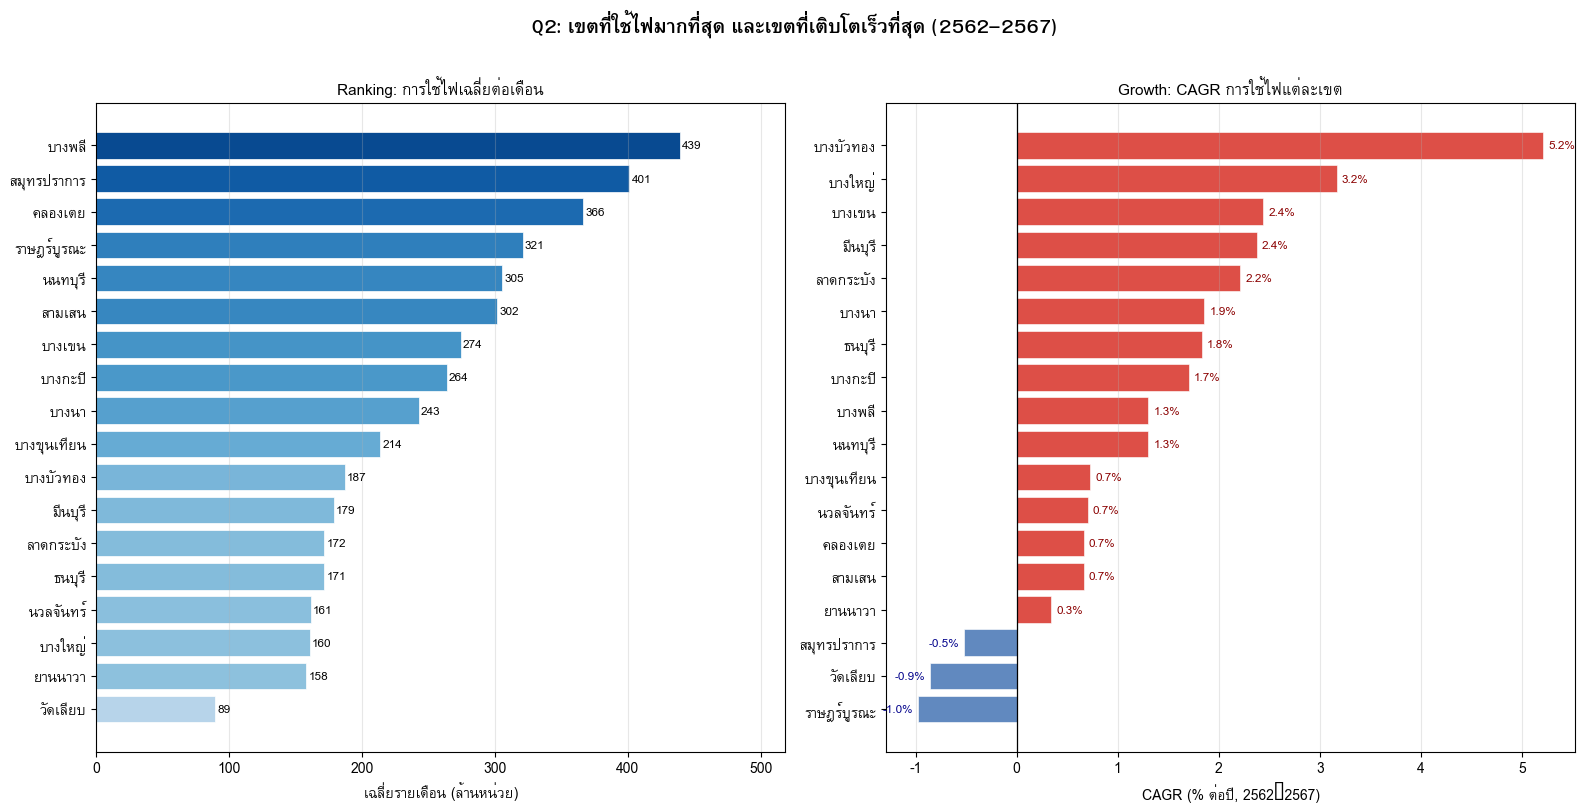


>>> INSIGHT Q2:
  เขตใช้ไฟสูงสุด 3 อันดับ : บางพลี, สมุทรปราการ, คลองเตย
  เขตโตเร็วสุด 3 อันดับ   : บางบัวทอง, บางใหญ่, บางเขน
  WHAT: เขตใหญ่เชิงพาณิชย์+อุตสาหกรรม ครองอันดับต้นด้าน consumption
  WHY : ย่านเหล่านี้มีโรงงาน ศูนย์การค้า อาคารสำนักงาน ทำงานตลอด 24 ชม.
  WHAT: เขตชานเมืองมักมี CAGR สูงกว่าเขตในเมืองที่ค่อนข้าง saturated
  WHY : การขยายตัวของที่อยู่อาศัยและนิคมอุตสาหกรรมรอบนอก BKK
  → ACTION: จัดลำดับลงทุนขยาย substation ในเขต high-CAGR ก่อนที่ capacity จะเต็ม


In [ ]:
# ============================================================
# Q2: DISTRICT RANKING & CAGR GROWTH
# ============================================================

# ── Ranking: ค่าเฉลี่ยรายเดือนทุกช่วงเวลา ───────────────────────────────────
district_avg = df[DISTRICTS].mean().sort_values(ascending=True)  # ascending for barh

# ── CAGR: ผลรวมรายปีของปีเต็มแรก (2019) และปีเต็มสุดท้าย (2024) ─────────────
annual_sum = (df[df['year_ce'].isin([2019, 2024])]
              .groupby('year_ce')[DISTRICTS].sum())
cagr = ((annual_sum.loc[2024] / annual_sum.loc[2019]) ** (1/5) - 1) * 100
cagr_sorted = cagr.sort_values(ascending=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# ใช้ y= แทน pad= เพื่อรองรับ matplotlib ทุกเวอร์ชั่น
fig.suptitle('Q2: เขตที่ใช้ไฟมากที่สุด และเขตที่เติบโตเร็วที่สุด (2562–2567)',
             fontsize=13, fontweight='bold', y=1.01)

# ── Panel 1: Ranking ──────────────────────────────────────────────────────────
norm = (district_avg.values - district_avg.min()) / (district_avg.max() - district_avg.min())
colors1 = plt.cm.Blues(0.3 + 0.6 * norm)  # gradient: ยิ่งใช้มาก ยิ่งเข้ม
ax1.barh(range(len(district_avg)), district_avg.values,
         color=colors1, edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(len(district_avg)))
ax1.set_yticklabels(district_avg.index, fontsize=10)
ax1.set_xlabel('เฉลี่ยรายเดือน (ล้านหน่วย)', fontsize=10)
ax1.set_title('Ranking: การใช้ไฟเฉลี่ยต่อเดือน', fontsize=11)
for i, v in enumerate(district_avg.values):
    ax1.text(v + 1.5, i, f'{v:.0f}', va='center', fontsize=8.5)
ax1.set_xlim(0, district_avg.max() * 1.18)
ax1.grid(axis='x', alpha=0.3)

# ── Panel 2: CAGR ─────────────────────────────────────────────────────────────
colors2 = ['#d73027' if v > 0 else '#4575b4' for v in cagr_sorted.values]
ax2.barh(range(len(cagr_sorted)), cagr_sorted.values,
         color=colors2, alpha=0.85, edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(len(cagr_sorted)))
ax2.set_yticklabels(cagr_sorted.index, fontsize=10)
ax2.set_xlabel('CAGR (% ต่อปี, 2562→2567)', fontsize=10)
ax2.set_title('Growth: CAGR การใช้ไฟแต่ละเขต', fontsize=11)
ax2.axvline(0, color='black', linewidth=0.9)
for i, v in enumerate(cagr_sorted.values):
    offset = 0.05 if v >= 0 else -0.35
    ax2.text(v + offset, i, f'{v:.1f}%', va='center', fontsize=8.5,
             color='darkred' if v > 0 else 'darkblue')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Insights ─────────────────────────────────────────────────────────────────
top3_size   = district_avg.sort_values(ascending=False).head(3)
top3_growth = cagr.sort_values(ascending=False).head(3)
print('\n>>> INSIGHT Q2:')
print(f'  เขตใช้ไฟสูงสุด 3 อันดับ : {", ".join(top3_size.index.tolist())}')
print(f'  เขตโตเร็วสุด 3 อันดับ   : {", ".join(top3_growth.index.tolist())}')
print('  WHAT: เขตใหญ่เชิงพาณิชย์+อุตสาหกรรม ครองอันดับต้นด้าน consumption')
print('  WHY : ย่านเหล่านี้มีโรงงาน ศูนย์การค้า อาคารสำนักงาน ทำงานตลอด 24 ชม.')
print('  WHAT: เขตชานเมืองมักมี CAGR สูงกว่าเขตในเมืองที่ค่อนข้าง saturated')
print('  WHY : การขยายตัวของที่อยู่อาศัยและนิคมอุตสาหกรรมรอบนอก BKK')
print('  → ACTION: จัดลำดับลงทุนขยาย substation ในเขต high-CAGR ก่อนที่ capacity จะเต็ม')

---
## Q3: รูปแบบฤดูกาลของแต่ละเขตแตกต่างกันอย่างไร (Seasonal Patterns)

### แนวคิดหลัก

**ปัญหาของการใช้ตัวเลขดิบเปรียบเทียบข้ามเขต:**
เขตคลองเตยใช้ไฟ ~430 ล้านหน่วย/เดือน ส่วนเขตวัดเลียบใช้แค่ ~95 ล้านหน่วย/เดือน
ถ้า plot ตัวเลขดิบในกราฟเดียวกัน เขตเล็กจะแบน จนมองไม่เห็น pattern ของตัวเอง

**วิธีแก้: Seasonal Index**

```
Seasonal Index = (ค่าเฉลี่ยเดือนนั้นของเขตนั้น ÷ ค่าเฉลี่ยรายปีของเขตนั้น) × 100
```

> **ตัวอย่าง:** เขตวัดเลียบ ใช้ไฟเฉลี่ยทั้งปี = 95 ล้านหน่วย/เดือน
> เดือน พ.ค. ใช้ไฟ = 111 ล้านหน่วย
> Seasonal Index เดือน พ.ค. = (111 ÷ 95) × 100 = **117**
> แปลว่า พ.ค. ของเขตนี้สูงกว่าค่าเฉลี่ยปี 17%

ผลลัพธ์: ทุกเขตอยู่บน scale เดียวกัน (รอบๆ 100) เปรียบเทียบ **รูปแบบ (pattern)** ข้ามเขตได้ยุติธรรม
โดยไม่ถูกขนาดของเขตบดบัง

**Heatmap** เป็นตัวเลือกที่เหมาะสมที่สุด เพราะแสดง 18 เขต × 12 เดือน = 216 ค่าในภาพเดียว
ทำให้เห็น cluster ของเขตที่มีพฤติกรรมคล้ายกัน และเดือนที่เป็น peak/low ได้พร้อมกันทันที

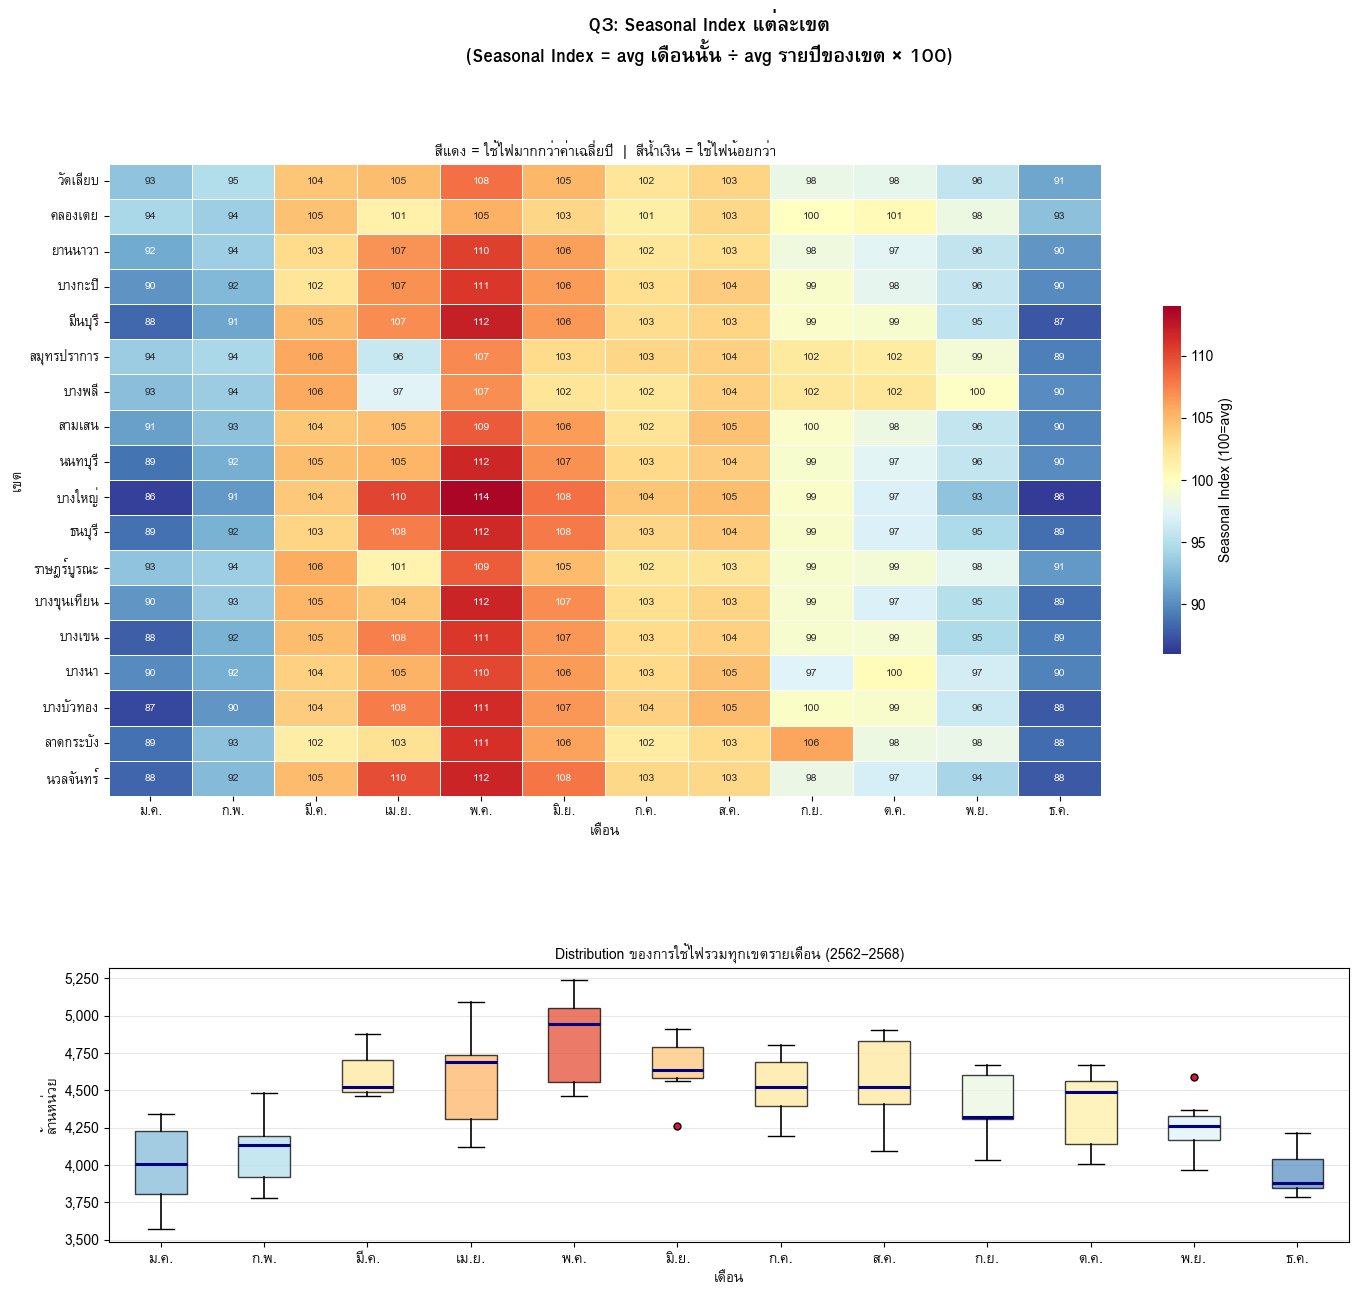


>>> INSIGHT Q3:
  WHAT: Peak เฉลี่ยทุกเขต = เดือน พ.ค. (Seasonal Index ≈ 110)
  WHAT: Low เฉลี่ยทุกเขต  = เดือน ธ.ค. (Seasonal Index ≈ 89)
  WHAT: เขตที่มี seasonal variation สูงสุด : บางใหญ่, มีนบุรี, บางบัวทอง
  WHAT: เขตที่มี seasonal variation ต่ำสุด  : คลองเตย, บางพลี, วัดเลียบ

  WHY : เม.ย.–พ.ค. = ฤดูร้อนไทย อุณหภูมิสูงสุดของปี → AC ทำงานเต็มกำลัง
        ทั้งที่อยู่อาศัย ห้างสรรพสินค้า และอาคารสำนักงาน
  WHY : พ.ย.–ม.ค. = ฤดูหนาว/ต้นปี อากาศเย็น → ความต้องการ cooling ลดลง
  WHY : เขตที่มี variation สูง = มีสัดส่วน residential สูง (AC-driven demand)
  WHY : เขตที่มี variation ต่ำ = dominated by industrial / 24-hr operation
        → base load สม่ำเสมอ ไม่แปรตามฤดูกาลมากนัก

  → ACTION: วางแผน demand-side management เดือน เม.ย.–พ.ค. ในเขต residential
  → ACTION: ใช้ seasonal index เป็น multiplier ใน load forecasting
  → ACTION: พิจารณา time-of-use pricing ในเขต industrial (low variation)
            เพื่อ shift load ออกจาก peak hour ได้มีประสิทธิภาพกว่าเขต residential


In [ ]:
# ============================================================
# Q3: SEASONAL PATTERNS BY DISTRICT
# ============================================================

MONTH_TH = {1:'ม.ค.',2:'ก.พ.',3:'มี.ค.',4:'เม.ย.',5:'พ.ค.',6:'มิ.ย.',
            7:'ก.ค.',8:'ส.ค.',9:'ก.ย.',10:'ต.ค.',11:'พ.ย.',12:'ธ.ค.'}
MONTH_LABELS = [MONTH_TH[i] for i in range(1, 13)]

# ── คำนวณ Seasonal Index ──────────────────────────────────────────────────────
# seasonal_index[district, month] = avg(month) / avg(all) × 100
# → normalize ต่อเขต ทำให้ pattern เปรียบเทียบข้ามเขตได้
seasonal_records = {}
for d in DISTRICTS:
    month_avg   = df.groupby('month_num')[d].mean()   # avg per month (12 values)
    overall_avg = df[d].mean()                         # grand average
    seasonal_records[d] = (month_avg / overall_avg * 100).values

# seasonal_df: rows=districts, cols=months
seasonal_df = pd.DataFrame(seasonal_records,
                            index=MONTH_LABELS).T

# ── Plot Layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs  = fig.add_gridspec(2, 1, height_ratios=[3, 1.3], hspace=0.38)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

fig.suptitle(
    'Q3: Seasonal Index แต่ละเขต\n(Seasonal Index = avg เดือนนั้น ÷ avg รายปีของเขต × 100)',
    fontsize=13, fontweight='bold', y=0.99)

# ── Panel 1: Heatmap ─────────────────────────────────────────────────────────
# RdYlBu_r: แดง=สูงกว่าเฉลี่ย, น้ำเงิน=ต่ำกว่า → เห็น hot/cold season ชัด
sns.heatmap(seasonal_df, ax=ax1,
            cmap='RdYlBu_r', vmin=86, vmax=114,
            annot=True, fmt='.0f', annot_kws={'size': 7.5},
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Seasonal Index (100=avg)', 'shrink': 0.55})
ax1.set_title('สีแดง = ใช้ไฟมากกว่าค่าเฉลี่ยปี  |  สีน้ำเงิน = ใช้ไฟน้อยกว่า',
              fontsize=10)
ax1.set_xlabel('เดือน', fontsize=10)
ax1.set_ylabel('เขต', fontsize=10)
ax1.tick_params(axis='y', labelsize=9)
ax1.tick_params(axis='x', labelsize=9, rotation=0)

# ── Panel 2: Boxplot (รายเดือน, total ทุกเขตรวม ทุกปี) ──────────────────────
monthly_data = [df[df['month_num'] == m]['total'].values for m in range(1, 13)]
bp = ax2.boxplot(monthly_data, labels=MONTH_LABELS, patch_artist=True,
                 medianprops=dict(color='navy', linewidth=2.2),
                 whiskerprops=dict(linewidth=1.2),
                 flierprops=dict(marker='o', markerfacecolor='crimson', markersize=5))

# ไล่สีกล่องตาม median (แดง=สูง, น้ำเงิน=ต่ำ)
medians = [np.median(d) for d in monthly_data]
med_max, med_min = max(medians), min(medians)
for patch, med in zip(bp['boxes'], medians):
    norm_m = (med - med_min) / (med_max - med_min)
    patch.set_facecolor(plt.cm.RdYlBu_r(0.15 + 0.7 * norm_m))
    patch.set_alpha(0.75)

ax2.set_title('Distribution ของการใช้ไฟรวมทุกเขตรายเดือน (2562–2568)', fontsize=10)
ax2.set_ylabel('ล้านหน่วย', fontsize=10)
ax2.set_xlabel('เดือน', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(axis='y', alpha=0.3)

plt.show()

# ── Insights ─────────────────────────────────────────────────────────────────
avg_seasonal  = seasonal_df.mean(axis=0)  # avg index ข้ามทุกเขต
peak_month    = avg_seasonal.idxmax()
low_month     = avg_seasonal.idxmin()
seasonal_range = seasonal_df.max(axis=1) - seasonal_df.min(axis=1)
high_var_dist  = seasonal_range.nlargest(3).index.tolist()
low_var_dist   = seasonal_range.nsmallest(3).index.tolist()

print('\n>>> INSIGHT Q3:')
print(f'  WHAT: Peak เฉลี่ยทุกเขต = เดือน {peak_month} (Seasonal Index ≈ {avg_seasonal[peak_month]:.0f})')
print(f'  WHAT: Low เฉลี่ยทุกเขต  = เดือน {low_month} (Seasonal Index ≈ {avg_seasonal[low_month]:.0f})')
print(f'  WHAT: เขตที่มี seasonal variation สูงสุด : {", ".join(high_var_dist)}')
print(f'  WHAT: เขตที่มี seasonal variation ต่ำสุด  : {", ".join(low_var_dist)}')
print()
print('  WHY : เม.ย.–พ.ค. = ฤดูร้อนไทย อุณหภูมิสูงสุดของปี → AC ทำงานเต็มกำลัง')
print('        ทั้งที่อยู่อาศัย ห้างสรรพสินค้า และอาคารสำนักงาน')
print('  WHY : พ.ย.–ม.ค. = ฤดูหนาว/ต้นปี อากาศเย็น → ความต้องการ cooling ลดลง')
print('  WHY : เขตที่มี variation สูง = มีสัดส่วน residential สูง (AC-driven demand)')
print('  WHY : เขตที่มี variation ต่ำ = dominated by industrial / 24-hr operation')
print('        → base load สม่ำเสมอ ไม่แปรตามฤดูกาลมากนัก')
print()
print('  → ACTION: วางแผน demand-side management เดือน เม.ย.–พ.ค. ในเขต residential')
print('  → ACTION: ใช้ seasonal index เป็น multiplier ใน load forecasting')
print('  → ACTION: พิจารณา time-of-use pricing ในเขต industrial (low variation)')
print('            เพื่อ shift load ออกจาก peak hour ได้มีประสิทธิภาพกว่าเขต residential')

---
## Summary & Actionable Plan

### สรุป EDA Insights

| คำถาม | ผลสรุป | นัยสำคัญ |
|-------|--------|----------|
| **Q1 Trend** | Trend เพิ่มต่อเนื่อง ชะลอช่วง COVID | หลัง COVID demand กลับมา + เพิ่มสูงกว่าเดิม |
| **Q1 Anomaly** | มีเดือนที่ Z-score เกิน ±2σ | ควรตรวจสอบเชิงลึกก่อนใส่ใน model |
| **Q2 Ranking** | คลองเตย / บางพลี / สมุทรปราการ ใช้ไฟมากสุด | เขตเชิงพาณิชย์+อุตสาหกรรมครอง top |
| **Q2 Growth** | เขตชานเมืองบางเขตมี CAGR สูงกว่าในเมือง | urbanization รอบนอก = demand ใหม่ |
| **Q3 Seasonal** | Peak = เม.ย.–พ.ค., Low = พ.ย.–ธ.ค. | เขต residential แปรปรวนกว่า industrial |

---
## แผนปฏิบัติการและข้อเสนอแนะ

### ระยะที่ 1: โครงสร้างพื้นฐานระบบไฟฟ้าและการวางแผนรับมือความต้องการที่เพิ่มขึ้น

**เร่งอัปเกรดพื้นที่ชานเมือง** : ลงทุนขยายสถานีไฟฟ้าในเขตบางบัวทองและบางใหญ่เป็นลำดับแรก
อัตราการเติบโตเกือบ 30% ใน 5 ปี บ่งชี้ว่าหากไม่เพิ่มขีดความสามารถของหม้อแปลงก่อนถึงช่วงฤดูร้อนปี 2569
ระบบไฟฟ้าในพื้นที่เหล่านี้มีความเสี่ยงสูงที่จะไม่เสถียร

**ระบบตอบสนองความต้องการสำหรับย่านอุตสาหกรรม** : นำโปรแกรม Demand Response (DR) มาใช้ในเขตบางพลีและสมุทรปราการ
โดยจูงใจให้ผู้ประกอบการอุตสาหกรรมเลื่อนการใช้ไฟในช่วงพีค (13.00–16.00 น. ฤดูร้อน)
เพื่อหลีกเลี่ยงการเดินเครื่องโรงไฟฟ้าสำรองที่มีต้นทุนสูง

### ระยะที่ 2: การจัดการด้านความต้องการใช้ไฟฟ้า (DSM)

**แคมเปญ "ประหยัดไฟ ลดร้อน"** : ช่วงมีนาคม–พฤษภาคมคือความเสี่ยงหลักต่อเสถียรภาพของระบบ
ควรเปิดโครงการอุดหนุนเครื่องปรับอากาศ Inverter ประสิทธิภาพสูงและโซลาร์รูฟท็อป
โดยมุ่งเป้าไปที่เขตที่อยู่อาศัยที่กำลังเติบโตเร็ว ได้แก่ บางบัวทอง และบางเขน

**ส่งเสริมโซลาร์รูฟท็อปในเขตที่อยู่อาศัย** : เขตบางบัวทองเป็นพื้นที่ที่เหมาะสมอย่างยิ่งสำหรับการติดตั้งโซลาร์บนหลังคาบ้าน
ซึ่งจะช่วยลดยอดการใช้ไฟในช่วงกลางวันที่พุ่งสูงจากการเปิดเครื่องปรับอากาศได้โดยตรง

### ระยะที่ 3: ประสิทธิภาพในการดำเนินงาน

**ทบทวนการใช้ประโยชน์จากทรัพย์สิน** : ในเขตที่ความต้องการใช้ไฟลดลง เช่น วัดเลียบ และราษฎร์บูรณะ
ควรตรวจสอบประสิทธิภาพของสินทรัพย์ที่มีอยู่ มีโอกาสปลดระวางอุปกรณ์จ่ายไฟเก่าที่มีประสิทธิภาพต่ำ
และโอนงบประมาณบำรุงรักษาไปสนับสนุนพื้นที่ที่เติบโตสูงทางฝั่งเหนือและตะวันตก

**บำรุงรักษาเชิงป้องกันตามฤดูกาล** : ใช้ข้อมูลแนวโน้มปี 2568 วางแผนงานบำรุงรักษาหลักในช่วง "ฤดูต่ำ" (พฤศจิกายน–มกราคม)
เพื่อให้ระบบพร้อมจ่ายไฟ 100% ในช่วงวิกฤต มีนาคม–พฤษภาคม

### ระยะที่ 4: การติดตามผลในอนาคต

**ติดตามข้อมูลครบปี 2568** : เมื่อได้รับข้อมูลเดือนธันวาคม 2568 ให้ตรวจสอบว่าอัตราการเติบโตชะลอตัวหรือไม่
หากยอดรวมปี 2568 ต่ำกว่าปี 2567 อาจสะท้อนสัญญาณเศรษฐกิจชะลอตัว
ซึ่งจะเปิดโอกาสให้ปรับแผนลงทุนโครงสร้างพื้นฐานให้เป็นไปอย่างค่อยเป็นค่อยไปและประหยัดงบประมาณมากขึ้น